<a href="https://colab.research.google.com/github/sumaiyaSultanaTarin/AML-nucleus-cytoplasm-segmentation/blob/main/AML_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**SETUP**

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/AML_ratio_project"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints_v2")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs_v2")

for folder in [PROJECT_ROOT, DATA_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Log dir:", LOG_DIR)

Project root: /content/drive/MyDrive/AML_ratio_project
Data dir: /content/drive/MyDrive/AML_ratio_project/data
Checkpoint dir: /content/drive/MyDrive/AML_ratio_project/checkpoints_v2
Log dir: /content/drive/MyDrive/AML_ratio_project/logs_v2


In [4]:
# Install packages
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless scikit-image statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("No GPU detected")

CUDA available: True
GPU name: Tesla T4
GPU memory: 15.6 GB


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Download WBCAtt+**

In [7]:
# WBCAtt+ images and masks
WBCATT_DIR = os.path.join(DATA_DIR, "wbcattplus")
IMG_MASK_DIR = os.path.join(WBCATT_DIR, "pbcseg_final_v1")
TAR_PATH = os.path.join(WBCATT_DIR, "pbcseg_final_v1.tar")

os.makedirs(WBCATT_DIR, exist_ok=True)

if not os.path.exists(IMG_MASK_DIR):
    print("Images/masks not found in Drive yet, downloading (only happens once)...")

    if not os.path.exists(TAR_PATH):
        !wget -q "https://huggingface.co/datasets/apple2373/wbcattplus/resolve/main/pbcseg_final_v1.tar" -O {TAR_PATH}
        print("Tar file downloaded.")

    !tar -xf {TAR_PATH} -C {WBCATT_DIR}
    print("Extracted.")
else:
    print("Images/masks already in Drive, skipping download.")

n_files = len(os.listdir(IMG_MASK_DIR)) if os.path.exists(IMG_MASK_DIR) else 0
print("Files found in", IMG_MASK_DIR, ":", n_files)

Images/masks already in Drive, skipping download.
Files found in /content/drive/MyDrive/AML_ratio_project/data/wbcattplus/pbcseg_final_v1 : 20596


In [8]:
# WBCAtt+ split CSVs (train/val/test attribute + path tables)
CSV_DIR = os.path.join(WBCATT_DIR, "dataset_txt")
os.makedirs(CSV_DIR, exist_ok=True)

csv_files = [
    "pbc_attr_v1_ccrop_train.csv",
    "pbc_attr_v1_ccrop_val.csv",
    "pbc_attr_v1_ccrop_test.csv",
]

for fname in csv_files:
    fpath = os.path.join(CSV_DIR, fname)
    if not os.path.exists(fpath):
        url = f"https://raw.githubusercontent.com/apple2373/wbcattplus/main/dataset_txt/{fname}"
        !wget -q {url} -O {fpath}
        print("Downloaded", fname)
    else:
        print(fname, "already exists, skipping")

pbc_attr_v1_ccrop_train.csv already exists, skipping
pbc_attr_v1_ccrop_val.csv already exists, skipping
pbc_attr_v1_ccrop_test.csv already exists, skipping


In [9]:
AML_DIR = "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU"

print("AML-LMU folder exists:", os.path.exists(AML_DIR))
if os.path.exists(AML_DIR):
    print("Top-level contents:", os.listdir(AML_DIR)[:10])

AML-LMU folder exists: True
Top-level contents: ['AML-Cytomorphology.sums', 'BAS', 'EBO', 'EOS', 'KSC', 'LYA', 'LYT', 'MMZ', 'MOB', 'MON']


In [10]:
LOCAL_DATA_DIR = "/content/wbcattplus_data"
IMG_MASK_DIR = os.path.join(LOCAL_DATA_DIR, "pbcseg_final_v1")
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if not os.path.exists(IMG_MASK_DIR):
    print("Extracting to local Colab storage (fast, one-time this session)...")
    !tar -xf {TAR_PATH} -C {LOCAL_DATA_DIR}

n_files = len(os.listdir(IMG_MASK_DIR)) if os.path.exists(IMG_MASK_DIR) else 0
print("Files found locally:", n_files)

Extracting to local Colab storage (fast, one-time this session)...
Files found locally: 20596


## **PHASE -01**

**Section 1 - Data (WBCAtt+)**

In [11]:
#1.1 — Load the split CSVs and audit
import pandas as pd

train_df = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_train.csv"))
val_df   = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_val.csv"))
test_df  = pd.read_csv(os.path.join(CSV_DIR, "pbc_attr_v1_ccrop_test.csv"))

print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))
print("total:", len(train_df) + len(val_df) + len(test_df))

train: 6169
val:   1030
test:  3099
total: 10298


In [12]:
#1.2 — Check mask pixel value
import cv2
import numpy as np

sample_paths = train_df["path"].sample(50, random_state=42).tolist()
all_values = set()

for p in sample_paths:
    mask_path = os.path.join(IMG_MASK_DIR, p).replace(".jpg", "_mask.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    if mask is not None:
        all_values.update(np.unique(mask).tolist())
    else:
        print("Mask not found for", p)

print("unique mask values across 50 images:", sorted(all_values))

unique mask values across 50 images: [0, 1, 2, 3, 4, 5]


In [13]:
def mask_to_classes(mask):
    """
    Raw WBCAtt+ mask (6 classes):
      0 = background, 1 = cytoplasm, 2 = nucleus,
      3 = red blood cell, 4 = platelet, 5 = vacuole

    Remapped to 3 training classes:
      0 = background (includes RBC, platelet)
      1 = cytoplasm  (includes vacuole)
      2 = nucleus
    """
    new_mask = np.zeros_like(mask, dtype=np.uint8)
    new_mask[mask == 1] = 1   # cytoplasm
    new_mask[mask == 5] = 1   # vacuole -> cytoplasm
    new_mask[mask == 2] = 2   # nucleus
    return new_mask

In [14]:
#1.4 — Dataset class
import torch
from torch.utils.data import Dataset

class WBCAttDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "path"]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = img_path.replace(".jpg", "_mask.png")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        mask = mask_to_classes(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [15]:
#1.5 — Augmentation AND Dataloaders
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

IMG_SIZE = 360   # native WBCAtt+ resolution
BATCH_SIZE = 8

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = WBCAttDataset(train_df, IMG_MASK_DIR, transform=train_aug)
val_dataset   = WBCAttDataset(val_df,   IMG_MASK_DIR, transform=val_aug)
test_dataset  = WBCAttDataset(test_df,  IMG_MASK_DIR, transform=val_aug)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("train batches:", len(train_loader))
print("val batches:  ", len(val_loader))
print("test batches: ", len(test_loader))

train batches: 772
val batches:   129
test batches:  388


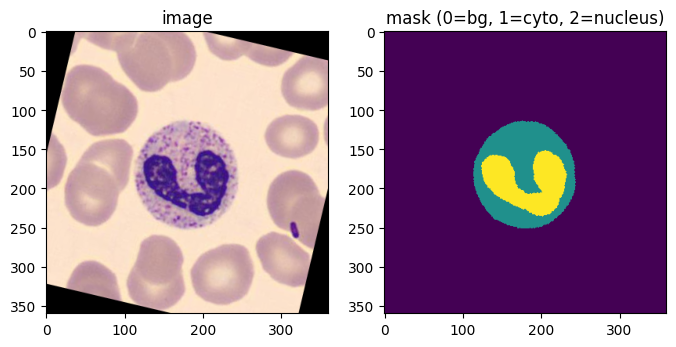

In [16]:
import matplotlib.pyplot as plt

image, mask = train_dataset[0]
image_np = image.permute(1, 2, 0).numpy()
image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image_np = np.clip(image_np, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image_np)
ax[0].set_title("image")
ax[1].imshow(mask, cmap="viridis", vmin=0, vmax=2)
ax[1].set_title("mask (0=bg, 1=cyto, 2=nucleus)")
plt.show()

**Section 2 - Model**

In [17]:
#Ratio Feedback Gate
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

class RatioFeedbackGate(nn.Module):
    def __init__(self, channels, hidden=8, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.probe_head = nn.Conv2d(channels, 3, kernel_size=1)
        self.mlp = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )
        self.last_ratio = None  # populated on every forward() call

    def forward(self, x):
        probe = self.probe_head(x)
        probe = F.softmax(probe, dim=1)

        cyto = probe[:, 1, :, :]
        nuc = probe[:, 2, :, :]

        nuc_area = nuc.sum(dim=[1, 2])
        cyto_area = cyto.sum(dim=[1, 2])
        ratio = torch.log((nuc_area + self.epsilon) / (cyto_area + self.epsilon))
        self.last_ratio = ratio  # exposed so TotalLoss can supervise it directly

        gate = self.mlp(ratio.unsqueeze(1))
        gate = gate.view(gate.size(0), gate.size(1), 1, 1)

        out = x + x * gate
        return out


class SegModel(nn.Module):
    def __init__(self, backbone, num_classes=3, use_rfg=True):
        super().__init__()

        if backbone == "attention_unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             decoder_attention_type="scse", in_channels=3, classes=num_classes)
        elif backbone == "unet":
            base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                             in_channels=3, classes=num_classes)

        self.encoder = base.encoder
        self.decoder = base.decoder
        self.seg_head = base.segmentation_head
        self.use_rfg = use_rfg

        if use_rfg:
            channels = self.seg_head[0].in_channels
            self.rfg = RatioFeedbackGate(channels)

    def forward(self, x):
        features = self.encoder(x)
        d = self.decoder(features)
        if self.use_rfg:
            d = self.rfg(d)
        out = self.seg_head(d)
        return out


def make_model(backbone, num_classes=3, use_rfg=True):
    return SegModel(backbone, num_classes, use_rfg)

In [18]:
for backbone in ["attention_unet", "unet"]:
    for use_rfg in [True, False]:
        model = make_model(backbone, num_classes=3, use_rfg=use_rfg)
        model = model.to(device)

        dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
        output = model(dummy_input)

        n_params = sum(p.numel() for p in model.parameters())
        print(f"{backbone:15s} use_rfg={str(use_rfg):5s} output={tuple(output.shape)} params={n_params:,}")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

attention_unet  use_rfg=True  output=(2, 3, 360, 360) params=24,550,861
attention_unet  use_rfg=False output=(2, 3, 360, 360) params=24,550,650
unet            use_rfg=True  output=(2, 3, 360, 360) params=24,436,870
unet            use_rfg=False output=(2, 3, 360, 360) params=24,436,659


**Section 3 - Loss**

In [19]:
#3.1 — Dice + Focal (standard segmentation losses)

class DiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = probs.shape[1]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)

        dice_per_class = (2 * intersection + self.epsilon) / (union + self.epsilon)
        return 1 - dice_per_class.mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [20]:
#3.2 — Ratio-consistency loss

class RatioConsistencyLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        super().__init__()
        self.epsilon = epsilon
        self.huber = nn.HuberLoss()

    def true_log_ratio(self, targets):
        true_nuc = (targets == 2).float().sum(dim=[1, 2])
        true_cyto = (targets == 1).float().sum(dim=[1, 2])
        return torch.log((true_nuc + self.epsilon) / (true_cyto + self.epsilon))

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        pred_nuc = probs[:, 2, :, :].sum(dim=[1, 2])
        pred_cyto = probs[:, 1, :, :].sum(dim=[1, 2])
        pred_ratio = torch.log((pred_nuc + self.epsilon) / (pred_cyto + self.epsilon))

        true_ratio = self.true_log_ratio(targets)

        return self.huber(pred_ratio, true_ratio)

In [21]:
#3.3 — Combined total loss

class TotalLoss(nn.Module):
    def __init__(self, lambda1=0.5, lambda2=0.3, lambda3=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.ratio = RatioConsistencyLoss()
        self.rfg_huber = nn.HuberLoss()
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.lambda3 = lambda3

    def forward(self, logits, targets, rfg_ratio=None):
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)
        loss = dice_loss + self.lambda1 * focal_loss

        if self.lambda2 > 0:
            ratio_loss = self.ratio(logits, targets)
            loss = loss + self.lambda2 * ratio_loss

        if rfg_ratio is not None:
            true_ratio = self.ratio.true_log_ratio(targets)
            loss = loss + self.lambda3 * self.rfg_huber(rfg_ratio, true_ratio)

        return loss

In [22]:
# Build dummy targets where nucleus is much smaller than cytoplasm
dummy_targets_imbalanced = torch.zeros(2, 360, 360, dtype=torch.long)
dummy_targets_imbalanced[:, 100:260, 100:260] = 1   # big cytoplasm region
dummy_targets_imbalanced[:, 160:200, 160:200] = 2   # small nucleus region
dummy_targets_imbalanced = dummy_targets_imbalanced.to(device)

# predicted logits that get the ratio WRONG (predict too much nucleus)
dummy_logits_bad = torch.zeros(2, 3, 360, 360).to(device)
dummy_logits_bad[:, 2, 100:260, 100:260] = 5.0   # predicts nucleus everywhere cytoplasm should be
dummy_logits_bad[:, 0, :, :] = -5.0

loss_with_ratio = TotalLoss(lambda1=0.5, lambda2=0.3).to(device)
loss_without_ratio = TotalLoss(lambda1=0.5, lambda2=0).to(device)

print("With ratio term:", loss_with_ratio(dummy_logits_bad, dummy_targets_imbalanced).item())
print("Without ratio term:", loss_without_ratio(dummy_logits_bad, dummy_targets_imbalanced).item())

With ratio term: 4.491828918457031
Without ratio term: 3.7106425762176514


**Section 4 - Training Infrastructure**

In [23]:
#4.1 — Metrics (Dice score, N:C ratio error)

def dice_score(logits, targets, num_classes=3, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)
    dice_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + epsilon) / (union + epsilon)
        dice_per_class.append(dice.item())
    return sum(dice_per_class) / num_classes


def nc_ratio_error(logits, targets, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)

    pred_nuc = (preds == 2).float().sum(dim=[1, 2])
    pred_cyto = (preds == 1).float().sum(dim=[1, 2])
    pred_ratio = pred_nuc / (pred_cyto + epsilon)

    true_nuc = (targets == 2).float().sum(dim=[1, 2])
    true_cyto = (targets == 1).float().sum(dim=[1, 2])
    true_ratio = true_nuc / (true_cyto + epsilon)

    error = torch.abs(pred_ratio - true_ratio)
    return error.mean().item()

In [24]:
#4.2 — Evaluation helper (runs on val/test set, no gradients)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    total_dice = 0
    total_ratio_error = 0
    n_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            if getattr(model, "use_rfg", False):
                loss = loss_fn(logits, masks, rfg_ratio=model.rfg.last_ratio)
            else:
                loss = loss_fn(logits, masks)

            total_loss += loss.item()
            total_dice += dice_score(logits, masks)
            total_ratio_error += nc_ratio_error(logits, masks)
            n_batches += 1

    return total_loss / n_batches, total_dice / n_batches, total_ratio_error / n_batches

In [25]:
def run_experiment(backbone, use_rfg, use_ratio_loss, seed, max_epochs=50, patience=8):
    torch.manual_seed(seed)
    run_name = f"{backbone}_rfg{int(use_rfg)}_ratio{int(use_ratio_loss)}_seed{seed}"
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")
    state_path = os.path.join(CHECKPOINT_DIR, run_name + "_state.pt")

    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    lambda2 = 0.3 if use_ratio_loss else 0
    loss_fn = TotalLoss(lambda1=0.5, lambda2=lambda2, lambda3=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    start_epoch = 0
    best_dice = 0
    best_ratio_error = float("inf")
    epochs_no_improve = 0
    history = []

    if os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        start_epoch = state["epoch"]
        best_dice = state["best_dice"]
        best_ratio_error = state["best_ratio_error"]
        epochs_no_improve = state["epochs_no_improve"]
        history = state["history"]
        print("Resuming", run_name, "from epoch", start_epoch)
    else:
        print("Starting run:", run_name)

    for epoch in range(start_epoch, max_epochs):
        model.train()
        train_loss, n_batches = 0, 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            if use_rfg:
                loss = loss_fn(logits, masks, rfg_ratio=model.rfg.last_ratio)
            else:
                loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= n_batches
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, val_loader, loss_fn)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error})


        is_better = (val_ratio_error < best_ratio_error) or (
            val_ratio_error == best_ratio_error and val_dice > best_dice
        )
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(), "epoch": epoch + 1,
                    "best_dice": best_dice, "best_ratio_error": best_ratio_error,
                    "epochs_no_improve": epochs_no_improve, "history": history}, state_path)

        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    history_df = pd.DataFrame(history)
    history_path = os.path.join(LOG_DIR, run_name + "_history.csv")
    history_df.to_csv(history_path, index=False)

    if os.path.exists(state_path):
        os.remove(state_path)

    print("Run finished:", run_name)
    print("Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)

    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error,
            "checkpoint_path": checkpoint_path, "history_path": history_path}

**Section 5 — Run the ablation grid**

In [26]:
configs = []

# Backbone A: Attention U-Net, full 4-way ablation, 3 seeds
for seed in [0, 1, 2]:
    configs.append({"backbone": "attention_unet", "use_rfg": False, "use_ratio_loss": False, "seed": seed})
    configs.append({"backbone": "attention_unet", "use_rfg": False, "use_ratio_loss": True,  "seed": seed})
    configs.append({"backbone": "attention_unet", "use_rfg": True,  "use_ratio_loss": False, "seed": seed})
    configs.append({"backbone": "attention_unet", "use_rfg": True,  "use_ratio_loss": True,  "seed": seed})

# Backbone B: plain U-Net, module on/off, ratio loss always on, 3 seeds
for seed in [0, 1, 2]:
    configs.append({"backbone": "unet", "use_rfg": False, "use_ratio_loss": True, "seed": seed})
    configs.append({"backbone": "unet", "use_rfg": True,  "use_ratio_loss": True, "seed": seed})

print("Total configs:", len(configs))

Total configs: 18


In [28]:
RESULTS_PATH = os.path.join(LOG_DIR, "all_results.csv")

if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    completed_runs = set(results_df["run_name"])
else:
    results_df = pd.DataFrame()
    completed_runs = set()

print("Already completed runs:", len(completed_runs))

for cfg in configs:
    run_name = f"{cfg['backbone']}_rfg{int(cfg['use_rfg'])}_ratio{int(cfg['use_ratio_loss'])}_seed{cfg['seed']}"

    if run_name in completed_runs:
        print("Skipping already-completed run:", run_name)
        continue

    result = run_experiment(
        backbone=cfg["backbone"],
        use_rfg=cfg["use_rfg"],
        use_ratio_loss=cfg["use_ratio_loss"],
        seed=cfg["seed"],
        max_epochs=50,
        patience=8,
    )

    results_df = pd.concat([results_df, pd.DataFrame([result])], ignore_index=True)
    results_df.to_csv(RESULTS_PATH, index=False)

print("All configs done.")
print(results_df)

Already completed runs: 17
Skipping already-completed run: attention_unet_rfg0_ratio0_seed0
Skipping already-completed run: attention_unet_rfg0_ratio1_seed0
Skipping already-completed run: attention_unet_rfg1_ratio0_seed0
Skipping already-completed run: attention_unet_rfg1_ratio1_seed0
Skipping already-completed run: attention_unet_rfg0_ratio0_seed1
Skipping already-completed run: attention_unet_rfg0_ratio1_seed1
Skipping already-completed run: attention_unet_rfg1_ratio0_seed1
Skipping already-completed run: attention_unet_rfg1_ratio1_seed1
Skipping already-completed run: attention_unet_rfg0_ratio0_seed2
Skipping already-completed run: attention_unet_rfg0_ratio1_seed2
Skipping already-completed run: attention_unet_rfg1_ratio0_seed2
Skipping already-completed run: attention_unet_rfg1_ratio1_seed2
Skipping already-completed run: unet_rfg0_ratio1_seed0
Skipping already-completed run: unet_rfg1_ratio1_seed0
Skipping already-completed run: unet_rfg0_ratio1_seed1
Skipping already-completed r

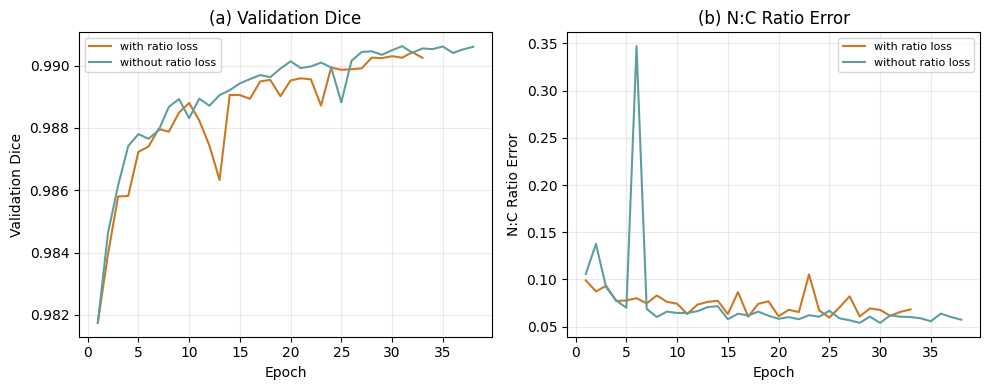

In [62]:
#Fig 3b - training curves, RFG-on configs with and without the ratio-consistency loss
seed_to_plot = 2

rfg_only_history = pd.read_csv(os.path.join(LOG_DIR, f"attention_unet_rfg1_ratio0_seed{seed_to_plot}_history.csv"))
full_method_history = pd.read_csv(os.path.join(LOG_DIR, f"attention_unet_rfg1_ratio1_seed{seed_to_plot}_history.csv"))

COLOR_WITH = "#CC7722"     # matches fig_ablation_bars.png orange
COLOR_WITHOUT = "#5F9EA0"  # matches fig_ablation_bars.png teal

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(full_method_history["epoch"], full_method_history["val_dice"], color=COLOR_WITH, label="with ratio loss")
axes[0].plot(rfg_only_history["epoch"], rfg_only_history["val_dice"], color=COLOR_WITHOUT, label="without ratio loss")
axes[0].set_title("(a) Validation Dice")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Dice")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(full_method_history["epoch"], full_method_history["val_ratio_error"], color=COLOR_WITH, label="with ratio loss")
axes[1].plot(rfg_only_history["epoch"], rfg_only_history["val_ratio_error"], color=COLOR_WITHOUT, label="without ratio loss")
axes[1].set_title("(b) N:C Ratio Error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("N:C Ratio Error")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_training_curves_rfg_ratioloss.png"), dpi=300)
plt.show()


**Section 6 — Results**

In [29]:
results_df = pd.read_csv(RESULTS_PATH)

parsed = results_df["run_name"].str.extract(
    r"^(?P<backbone>.+)_rfg(?P<use_rfg>\d)_ratio(?P<use_ratio_loss>\d)_seed(?P<seed>\d+)$"
)
results_df["backbone"] = parsed["backbone"]
results_df["use_rfg"] = parsed["use_rfg"].astype(int).astype(bool)
results_df["use_ratio_loss"] = parsed["use_ratio_loss"].astype(int).astype(bool)
results_df["seed"] = parsed["seed"].astype(int)

results_df.to_csv(RESULTS_PATH, index=False)

table = results_df.groupby(["backbone", "use_rfg", "use_ratio_loss"]).agg(
    dice_mean=("best_dice", "mean"),
    dice_std=("best_dice", "std"),
    ratio_err_mean=("best_ratio_error", "mean"),
    ratio_err_std=("best_ratio_error", "std"),
    n_seeds=("seed", "count"),
).reset_index()

table["Dice"] = table["dice_mean"].round(4).astype(str) + " ± " + table["dice_std"].round(4).astype(str)
table["N:C Ratio Error"] = table["ratio_err_mean"].round(4).astype(str) + " ± " + table["ratio_err_std"].round(4).astype(str)

print(table[["backbone", "use_rfg", "use_ratio_loss", "n_seeds", "Dice", "N:C Ratio Error"]].to_string(index=False))

      backbone  use_rfg  use_ratio_loss  n_seeds            Dice N:C Ratio Error
attention_unet    False           False        3 0.9903 ± 0.0004  0.0572 ± 0.002
attention_unet    False            True        3 0.9893 ± 0.0004  0.062 ± 0.0022
attention_unet     True           False        3 0.9899 ± 0.0006  0.057 ± 0.0035
attention_unet     True            True        3 0.9892 ± 0.0012 0.0607 ± 0.0037
          unet    False            True        3 0.9885 ± 0.0011  0.0638 ± 0.005
          unet     True            True        3 0.9894 ± 0.0007 0.0602 ± 0.0018


Section 6b — Paired significance test across seeds

In [30]:
from scipy import stats

def paired_test(df, backbone, group_a, group_b, metric):
    """group_a/group_b are (use_rfg, use_ratio_loss) tuples.
    Returns paired t-test stats for (group_b - group_a), matched by seed."""
    a = df[(df.backbone == backbone) & (df.use_rfg == group_a[0]) & (df.use_ratio_loss == group_a[1])]
    b = df[(df.backbone == backbone) & (df.use_rfg == group_b[0]) & (df.use_ratio_loss == group_b[1])]
    merged = a[["seed", metric]].merge(b[["seed", metric]], on="seed", suffixes=("_a", "_b"))
    if len(merged) < 2:
        return None
    diff = merged[f"{metric}_b"] - merged[f"{metric}_a"]
    t_stat, p_val = stats.ttest_rel(merged[f"{metric}_b"], merged[f"{metric}_a"])
    return {"n_seeds": len(merged), "mean_diff": diff.mean(), "t_stat": t_stat, "p_value": p_val}

baseline = (False, False)
comparisons = [
    ("ratio-loss only vs baseline", (False, True)),
    ("RFG only vs baseline", (True, False)),
    ("full method vs baseline", (True, True)),
]

print("Paired t-test across matched seeds, attention_unet backbone")
print("(positive mean_diff = worse ratio error / higher dice than baseline)\n")
for label, group in comparisons:
    for metric in ["best_ratio_error", "best_dice"]:
        result = paired_test(results_df, "attention_unet", baseline, group, metric)
        if result is None:
            print(f"{label:30s} [{metric}]: not enough matched seeds")
            continue
        sig = "significant (p<0.05)" if result["p_value"] < 0.05 else "not significant"
        print(f"{label:30s} [{metric}]: mean_diff={result['mean_diff']:+.4f}, "
              f"p={result['p_value']:.4f} ({sig}), n={result['n_seeds']}")
    print()

print("U-Net control - RFG on vs RFG off (ratio loss on in both):")
for metric in ["best_ratio_error", "best_dice"]:
    result = paired_test(results_df, "unet", (False, True), (True, True), metric)
    if result is None:
        print(f"  [{metric}]: not enough matched seeds")
        continue
    sig = "significant (p<0.05)" if result["p_value"] < 0.05 else "not significant"
    print(f"  [{metric}]: mean_diff={result['mean_diff']:+.4f}, p={result['p_value']:.4f} ({sig}), n={result['n_seeds']}")

Paired t-test across matched seeds, attention_unet backbone
(positive mean_diff = worse ratio error / higher dice than baseline)

ratio-loss only vs baseline    [best_ratio_error]: mean_diff=+0.0048, p=0.0795 (not significant), n=3
ratio-loss only vs baseline    [best_dice]: mean_diff=-0.0010, p=0.0876 (not significant), n=3

RFG only vs baseline           [best_ratio_error]: mean_diff=-0.0002, p=0.9450 (not significant), n=3
RFG only vs baseline           [best_dice]: mean_diff=-0.0004, p=0.3961 (not significant), n=3

full method vs baseline        [best_ratio_error]: mean_diff=+0.0035, p=0.1561 (not significant), n=3
full method vs baseline        [best_dice]: mean_diff=-0.0011, p=0.1706 (not significant), n=3

U-Net control - RFG on vs RFG off (ratio loss on in both):
  [best_ratio_error]: mean_diff=-0.0036, p=0.4276 (not significant), n=3
  [best_dice]: mean_diff=+0.0009, p=0.4389 (not significant), n=3


In [31]:
def per_class_dice(logits, targets, epsilon=1e-6):
    preds = torch.argmax(logits, dim=1)
    names = ["background", "cytoplasm", "nucleus"]
    scores = {}
    for c, name in enumerate(names):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + epsilon) / (union + epsilon)
        scores[name] = round(dice.item(), 4)
    return scores

# Selection matches the fixed epoch-selection criterion: lowest mean ratio
# error is primary, Dice is only a tiebreaker. Previously this sorted by
# dice_mean first, which could pick a config that was not actually best at
# the thing this study is about protecting - the same bug that was fixed
# inside run_experiment's per-epoch checkpoint selection.
best_config = table.sort_values(
    by=["ratio_err_mean", "dice_mean"], ascending=[True, False]
).iloc[0]
print("Best config found (lowest mean ratio error, Dice as tiebreaker):")
print(best_config[["backbone", "use_rfg", "use_ratio_loss", "Dice", "N:C Ratio Error"]])

PHASE2_BACKBONE = best_config["backbone"]
PHASE2_USE_RFG = bool(best_config["use_rfg"])

# `table` only has per-config means across 3 seeds; pick whichever specific
# seed's saved checkpoint achieved the best ratio error for this config,
# since that is the actual set of weights available on disk.
matching_seeds = results_df[
    (results_df["backbone"] == best_config["backbone"]) &
    (results_df["use_rfg"] == best_config["use_rfg"]) &
    (results_df["use_ratio_loss"] == best_config["use_ratio_loss"])
]
best_seed_row = matching_seeds.sort_values("best_ratio_error").iloc[0]
best_run_name = best_seed_row["run_name"]
print("Loading checkpoint:", best_run_name)

best_model = make_model(PHASE2_BACKBONE, num_classes=3, use_rfg=PHASE2_USE_RFG).to(device)
best_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, best_run_name + ".pt"), map_location=device))
best_model.eval()

config_groups = table[["backbone", "use_rfg", "use_ratio_loss"]].drop_duplicates()

per_class_results = []
for _, row in config_groups.iterrows():
    run_name = f"{row['backbone']}_rfg{int(row['use_rfg'])}_ratio{int(row['use_ratio_loss'])}_seed0"
    model = make_model(row["backbone"], num_classes=3, use_rfg=bool(row["use_rfg"])).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, run_name + ".pt"), map_location=device))
    model.eval()

    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    with torch.no_grad():
        logits = model(images)

    scores = per_class_dice(logits, masks)
    scores.update({"backbone": row["backbone"], "use_rfg": row["use_rfg"], "use_ratio_loss": row["use_ratio_loss"]})
    per_class_results.append(scores)
    print(run_name, scores)

per_class_df = pd.DataFrame(per_class_results)
per_class_df.to_csv(os.path.join(LOG_DIR, "per_class_dice_all_configs.csv"), index=False)

Best config found (lowest mean ratio error, Dice as tiebreaker):
backbone            attention_unet
use_rfg                       True
use_ratio_loss               False
Dice               0.9899 ± 0.0006
N:C Ratio Error     0.057 ± 0.0035
Name: 2, dtype: object
Loading checkpoint: attention_unet_rfg1_ratio0_seed2
attention_unet_rfg0_ratio0_seed0 {'background': 0.9996, 'cytoplasm': 0.9906, 'nucleus': 0.9959, 'backbone': 'attention_unet', 'use_rfg': False, 'use_ratio_loss': False}
attention_unet_rfg0_ratio1_seed0 {'background': 0.9995, 'cytoplasm': 0.9897, 'nucleus': 0.9953, 'backbone': 'attention_unet', 'use_rfg': False, 'use_ratio_loss': True}
attention_unet_rfg1_ratio0_seed0 {'background': 0.9995, 'cytoplasm': 0.9899, 'nucleus': 0.9953, 'backbone': 'attention_unet', 'use_rfg': True, 'use_ratio_loss': False}
attention_unet_rfg1_ratio1_seed0 {'background': 0.9996, 'cytoplasm': 0.9902, 'nucleus': 0.9956, 'backbone': 'attention_unet', 'use_rfg': True, 'use_ratio_loss': True}
unet_rfg0_ra

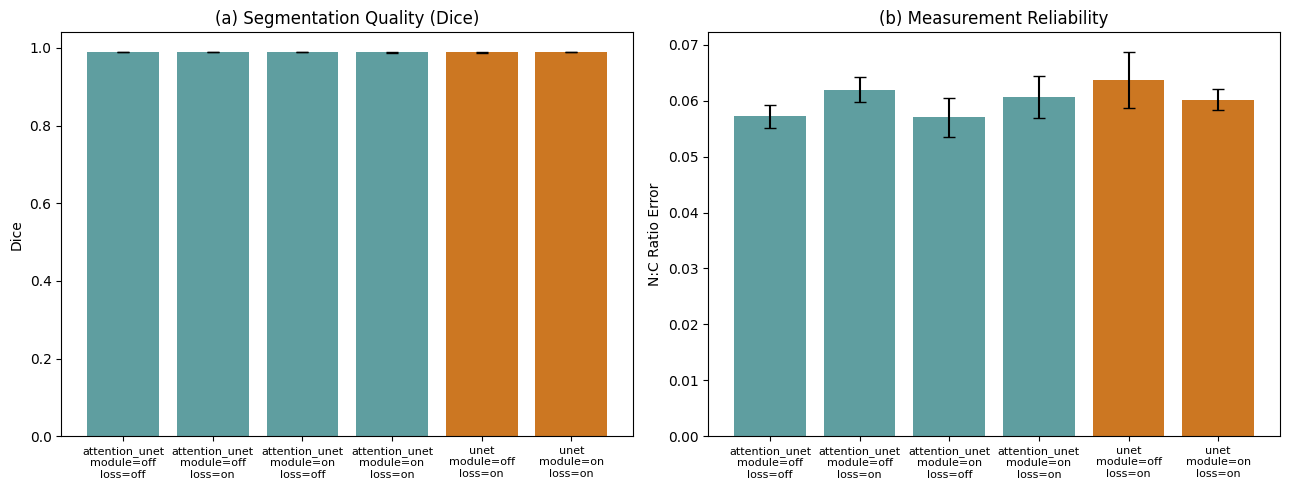

In [32]:
table["config_label"] = table.apply(
    lambda r: f"{r['backbone']}\nmodule={'on' if r['use_rfg'] else 'off'}\nloss={'on' if r['use_ratio_loss'] else 'off'}", axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#5F9EA0" if b == "attention_unet" else "#CC7722" for b in table["backbone"]]

axes[0].bar(table["config_label"], table["dice_mean"], yerr=table["dice_std"], capsize=4, color=colors)
axes[0].set_ylabel("Dice"); axes[0].set_title("(a) Segmentation Quality (Dice)")
axes[0].tick_params(axis='x', labelsize=8)

axes[1].bar(table["config_label"], table["ratio_err_mean"], yerr=table["ratio_err_std"], capsize=4, color=colors)
axes[1].set_ylabel("N:C Ratio Error"); axes[1].set_title("(b) Measurement Reliability")
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_ablation_bars.png"), dpi=300)
plt.show()

RFG mechanism check

In [33]:
def get_probe_ratio(model, images):
    with torch.no_grad():
        features = model.encoder(images)
        d = model.decoder(features)
        probe = torch.softmax(model.rfg.probe_head(d), dim=1)
        cyto, nuc = probe[:, 1], probe[:, 2]
        r = torch.log((nuc.sum(dim=[1,2]) + 1e-6) / (cyto.sum(dim=[1,2]) + 1e-6))
    return r

rfg_config_types = ["attention_unet_rfg1_ratio0", "attention_unet_rfg1_ratio1", "unet_rfg1_ratio1"]
rfg_configs = [f"{cfg}_seed{seed}" for cfg in rfg_config_types for seed in [0, 1, 2]]

correlation_results = []
for run_name in rfg_configs:
    backbone = "attention_unet" if "attention_unet" in run_name else "unet"
    model = make_model(backbone, num_classes=3, use_rfg=True).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, run_name + ".pt"), map_location=device))
    model.eval()

    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)

    r_pred = get_probe_ratio(model, images)
    true_nuc = (masks == 2).float().sum(dim=[1,2])
    true_cyto = (masks == 1).float().sum(dim=[1,2])
    r_true = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

    correlation = torch.corrcoef(torch.stack([r_pred.cpu(), r_true.cpu()]))[0,1].item()
    correlation_results.append({"run_name": run_name, "correlation": correlation})
    print(f"{run_name}: correlation = {correlation:.4f}")

correlation_df = pd.DataFrame(correlation_results)
correlation_df["config_type"] = correlation_df["run_name"].str.replace(r"_seed\d+$", "", regex=True)
correlation_df.to_csv(os.path.join(LOG_DIR, "rfg_correlation_check.csv"), index=False)

print()
print("Per config-type summary (mean +/- std across 3 seeds, single batch):")
print(correlation_df.groupby("config_type")["correlation"].agg(["mean", "std"]).to_string())

attention_unet_rfg1_ratio0_seed0: correlation = 0.9995
attention_unet_rfg1_ratio0_seed1: correlation = 0.9996
attention_unet_rfg1_ratio0_seed2: correlation = 0.9988
attention_unet_rfg1_ratio1_seed0: correlation = 0.9996
attention_unet_rfg1_ratio1_seed1: correlation = 0.9979
attention_unet_rfg1_ratio1_seed2: correlation = 0.9997
unet_rfg1_ratio1_seed0: correlation = 0.9975
unet_rfg1_ratio1_seed1: correlation = 0.9985
unet_rfg1_ratio1_seed2: correlation = 0.9978

Per config-type summary (mean +/- std across 3 seeds, single batch):
                                mean       std
config_type                                   
attention_unet_rfg1_ratio0  0.999321  0.000413
attention_unet_rfg1_ratio1  0.999080  0.001034
unet_rfg1_ratio1            0.997937  0.000540


In [34]:
def get_full_correlation(model, loader):
    all_r_pred, all_r_true = [], []
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        r_pred = get_probe_ratio(model, images)
        true_nuc = (masks == 2).float().sum(dim=[1,2])
        true_cyto = (masks == 1).float().sum(dim=[1,2])
        r_true = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))
        all_r_pred.append(r_pred.cpu())
        all_r_true.append(r_true.cpu())
    all_r_pred = torch.cat(all_r_pred)
    all_r_true = torch.cat(all_r_true)
    return torch.corrcoef(torch.stack([all_r_pred, all_r_true]))[0,1].item(), len(all_r_pred)

full_correlation_results = []
for run_name in rfg_configs:
    backbone = "attention_unet" if "attention_unet" in run_name else "unet"
    model = make_model(backbone, num_classes=3, use_rfg=True).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, run_name + ".pt"), map_location=device))
    model.eval()
    corr, n = get_full_correlation(model, val_loader)
    print(f"{run_name}: correlation = {corr:.4f} (n={n} images)")
    full_correlation_results.append({"run_name": run_name, "correlation": corr, "n_images": n})

full_correlation_df = pd.DataFrame(full_correlation_results)
full_correlation_df["config_type"] = full_correlation_df["run_name"].str.replace(r"_seed\d+$", "", regex=True)
full_correlation_df.to_csv(os.path.join(LOG_DIR, "rfg_full_correlation_check.csv"), index=False)

print()
print("Per config-type summary (mean +/- std across 3 seeds, full val set):")
print(full_correlation_df.groupby("config_type")["correlation"].agg(["mean", "std"]).to_string())

attention_unet_rfg1_ratio0_seed0: correlation = 0.9859 (n=1030 images)
attention_unet_rfg1_ratio0_seed1: correlation = 0.9838 (n=1030 images)
attention_unet_rfg1_ratio0_seed2: correlation = 0.9889 (n=1030 images)
attention_unet_rfg1_ratio1_seed0: correlation = 0.9868 (n=1030 images)
attention_unet_rfg1_ratio1_seed1: correlation = 0.9823 (n=1030 images)
attention_unet_rfg1_ratio1_seed2: correlation = 0.9866 (n=1030 images)
unet_rfg1_ratio1_seed0: correlation = 0.9861 (n=1030 images)
unet_rfg1_ratio1_seed1: correlation = 0.9764 (n=1030 images)
unet_rfg1_ratio1_seed2: correlation = 0.9890 (n=1030 images)

Per config-type summary (mean +/- std across 3 seeds, full val set):
                                mean       std
config_type                                   
attention_unet_rfg1_ratio0  0.986215  0.002572
attention_unet_rfg1_ratio1  0.985204  0.002554
unet_rfg1_ratio1            0.983824  0.006628


## **PHASE 02**

In [35]:
def segment_cell_color(image_rgb, erode_size=15, nucleus_v_percentile=35,
                        nucleus_s_percentile=60, min_nucleus_component_frac=0.05):
    """
    image_rgb: HxWx3 uint8 RGB image
    Returns: HxW uint8 mask, 0=background, 1=cytoplasm, 2=nucleus
    """
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    cell_candidate = ((h > 100) & (h < 180) & (s > 35)).astype(np.uint8)

    noise_kernel = np.ones((3, 3), np.uint8)
    cell_candidate = cv2.morphologyEx(cell_candidate, cv2.MORPH_OPEN, noise_kernel)

    if cell_candidate.sum() == 0:
        return np.zeros(image_rgb.shape[:2], dtype=np.uint8)

    erode_kernel = np.ones((erode_size, erode_size), np.uint8)
    eroded = cv2.erode(cell_candidate, erode_kernel)

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(eroded, connectivity=8)
    H, W = image_rgb.shape[:2]
    center = np.array([W / 2, H / 2])

    if n_labels <= 1:
        main_cell_mask = cell_candidate
    else:
        dists = [np.linalg.norm(centroids[i] - center) for i in range(1, n_labels)]
        seed_label = 1 + int(np.argmin(dists))
        seed_mask = (labels == seed_label).astype(np.uint8)
        grown = cv2.dilate(seed_mask, erode_kernel)
        main_cell_mask = (grown & cell_candidate).astype(np.uint8)

    # --- ADAPTIVE nucleus threshold: based on this cell's own pixel distribution ---
    cell_pixels_mask = main_cell_mask == 1
    v_in_cell = v[cell_pixels_mask]
    s_in_cell = s[cell_pixels_mask]

    if len(v_in_cell) == 0:
        nucleus_mask = np.zeros_like(main_cell_mask)
    else:
        v_thresh = np.percentile(v_in_cell, nucleus_v_percentile)
        s_thresh = np.percentile(s_in_cell, nucleus_s_percentile)

        nucleus_raw = ((v <= v_thresh) & (s >= s_thresh) & cell_pixels_mask).astype(np.uint8)
        nucleus_raw = cv2.morphologyEx(nucleus_raw, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

        # keep only significant connected components, drop speckle noise
        nucleus_mask = np.zeros_like(nucleus_raw)
        n_nuc_labels, nuc_labels, nuc_stats, _ = cv2.connectedComponentsWithStats(nucleus_raw, connectivity=8)

        if n_nuc_labels > 1:
            total_nuc_area = nucleus_raw.sum()
            if total_nuc_area > 0:
                for lbl in range(1, n_nuc_labels):
                    area = nuc_stats[lbl, cv2.CC_STAT_AREA]
                    if area >= min_nucleus_component_frac * total_nuc_area:
                        nucleus_mask[nuc_labels == lbl] = 1
            nucleus_mask = cv2.morphologyEx(nucleus_mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
            nucleus_mask = nucleus_mask & main_cell_mask

    mask = np.zeros((H, W), dtype=np.uint8)
    mask[main_cell_mask == 1] = 1
    mask[nucleus_mask == 1] = 2
    return mask

In [36]:
import random

random.seed(42)

blast_classes = ["MYO", "MOB", "PMO", "PMB", "MYB", "MMZ"]
control_classes = ["BAS", "EBO", "EOS", "KSC", "LYA", "LYT", "MON", "NGB", "NGS"]

def sample_class(class_name, n):
    class_dir = os.path.join(AML_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(".tiff")]
    n = min(n, len(files))  # in case a class has fewer than requested
    chosen = random.sample(files, n)
    return [{"class": class_name, "filename": f, "path": os.path.join(class_dir, f)} for f in chosen]

subset = []
for c in blast_classes:
    subset += sample_class(c, 45)
for c in control_classes:
    subset += sample_class(c, 20)

subset_df = pd.DataFrame(subset)
print("Total subset size:", len(subset_df))
print(subset_df["class"].value_counts())

subset_df.to_csv(os.path.join(LOG_DIR, "aml_subset_450.csv"), index=False)

Total subset size: 357
class
MYO    45
PMO    45
MYB    42
MOB    26
BAS    20
EOS    20
EBO    20
NGB    20
NGS    20
MON    20
LYT    20
PMB    18
MMZ    15
KSC    15
LYA    11
Name: count, dtype: int64


In [37]:
AML_MASK_DIR = os.path.join(DATA_DIR, "aml_pseudo_masks")
os.makedirs(AML_MASK_DIR, exist_ok=True)

failed = []

for idx, row in subset_df.iterrows():
    image_bgr = cv2.imread(row["path"])
    if image_bgr is None:
        failed.append(row["path"])
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask = segment_cell_color(image_rgb, erode_size=35)

    cell_fraction = (mask > 0).mean()
    if cell_fraction < 0.02 or cell_fraction > 0.85:
        failed.append(row["path"])
        continue  # do not save a mask we already know is broken

    mask_filename = row["filename"].replace(".tiff", "_mask.png")
    cv2.imwrite(os.path.join(AML_MASK_DIR, mask_filename), mask)

    if idx % 50 == 0:
        print(f"Processed {idx}/{len(subset_df)}")

print("Done. Flagged as possibly bad:", len(failed))
print(failed[:10])

# Previously `failed` was only printed, never acted on: masks for these
# images were still written to disk and the images stayed in subset_df with
# broken pseudo-labels (near-empty or near-whole-image segmentation).
subset_df = subset_df[~subset_df["path"].isin(failed)].reset_index(drop=True)
print("Subset size after dropping cell-fraction-flagged images:", len(subset_df))

Processed 0/357
Processed 50/357
Processed 100/357
Processed 150/357
Processed 200/357
Processed 250/357
Processed 300/357
Processed 350/357
Done. Flagged as possibly bad: 3
['/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_3161.tiff', '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0015.tiff', '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/NGS/NGS_3828.tiff']
Subset size after dropping cell-fraction-flagged images: 354


In [38]:
def qc_nucleus_fragmentation(mask, max_components=3, min_component_frac=0.05):
    """
    Flags a mask if the nucleus (class 2) is broken into more than
    max_components significant disconnected pieces.
    """
    nucleus = (mask == 2).astype(np.uint8)
    if nucleus.sum() == 0:
        return True, 0

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(nucleus, connectivity=8)
    total_area = nucleus.sum()

    component_areas = stats[1:, cv2.CC_STAT_AREA]
    significant = component_areas[component_areas >= min_component_frac * total_area]

    n_significant = len(significant)
    is_bad = n_significant > max_components
    return is_bad, n_significant


frag_flagged = []

for idx, row in subset_df.iterrows():
    mask_path = os.path.join(AML_MASK_DIR, row["filename"].replace(".tiff", "_mask.png"))
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        continue
    is_bad, n_comp = qc_nucleus_fragmentation(mask)
    if is_bad:
        frag_flagged.append({"path": row["path"], "n_components": n_comp})

print("Fragmented nucleus masks flagged:", len(frag_flagged))
for f in frag_flagged[:15]:
    print(f)

Fragmented nucleus masks flagged: 2
{'path': '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_2002.tiff', 'n_components': 5}
{'path': '/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0006.tiff', 'n_components': 4}


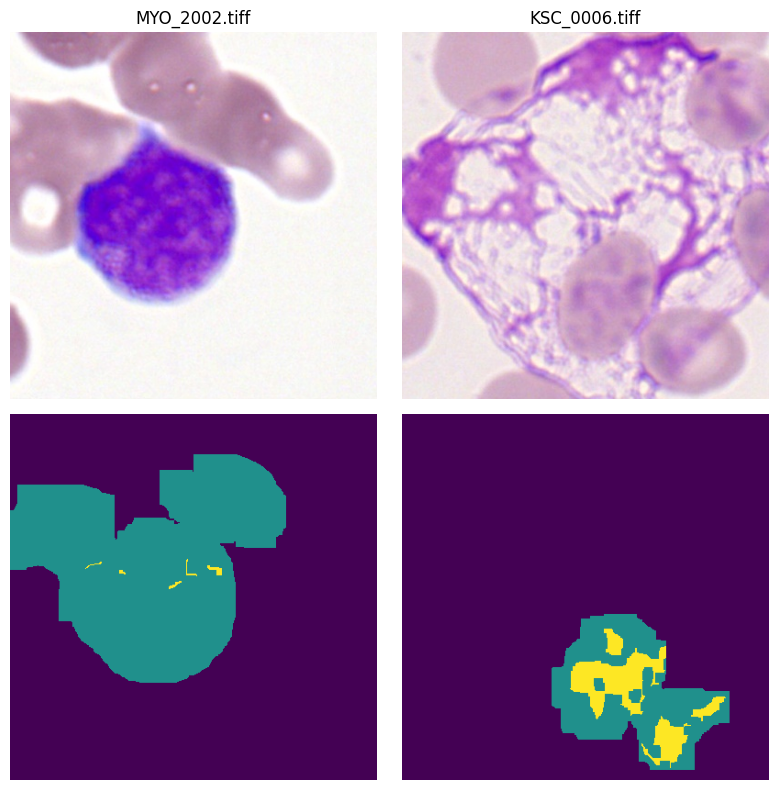

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for i, path in enumerate([
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_2002.tiff",
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0006.tiff",
]):
    filename = os.path.basename(path)
    mask_path = os.path.join(AML_MASK_DIR, filename.replace(".tiff", "_mask.png"))

    image_bgr = cv2.imread(path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    axes[0, i].imshow(image_rgb); axes[0, i].axis("off"); axes[0, i].set_title(filename)
    axes[1, i].imshow(mask, cmap="viridis", vmin=0, vmax=2); axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [40]:
bad_paths = [
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/MYO/MYO_2002.tiff",
    "/content/drive/MyDrive/PKG - AML-Cytomorphology_LMU/KSC/KSC_0006.tiff",
]
subset_df = subset_df[~subset_df["path"].isin(bad_paths)].reset_index(drop=True)
print("Subset size after dropping flagged images:", len(subset_df))

Subset size after dropping flagged images: 352


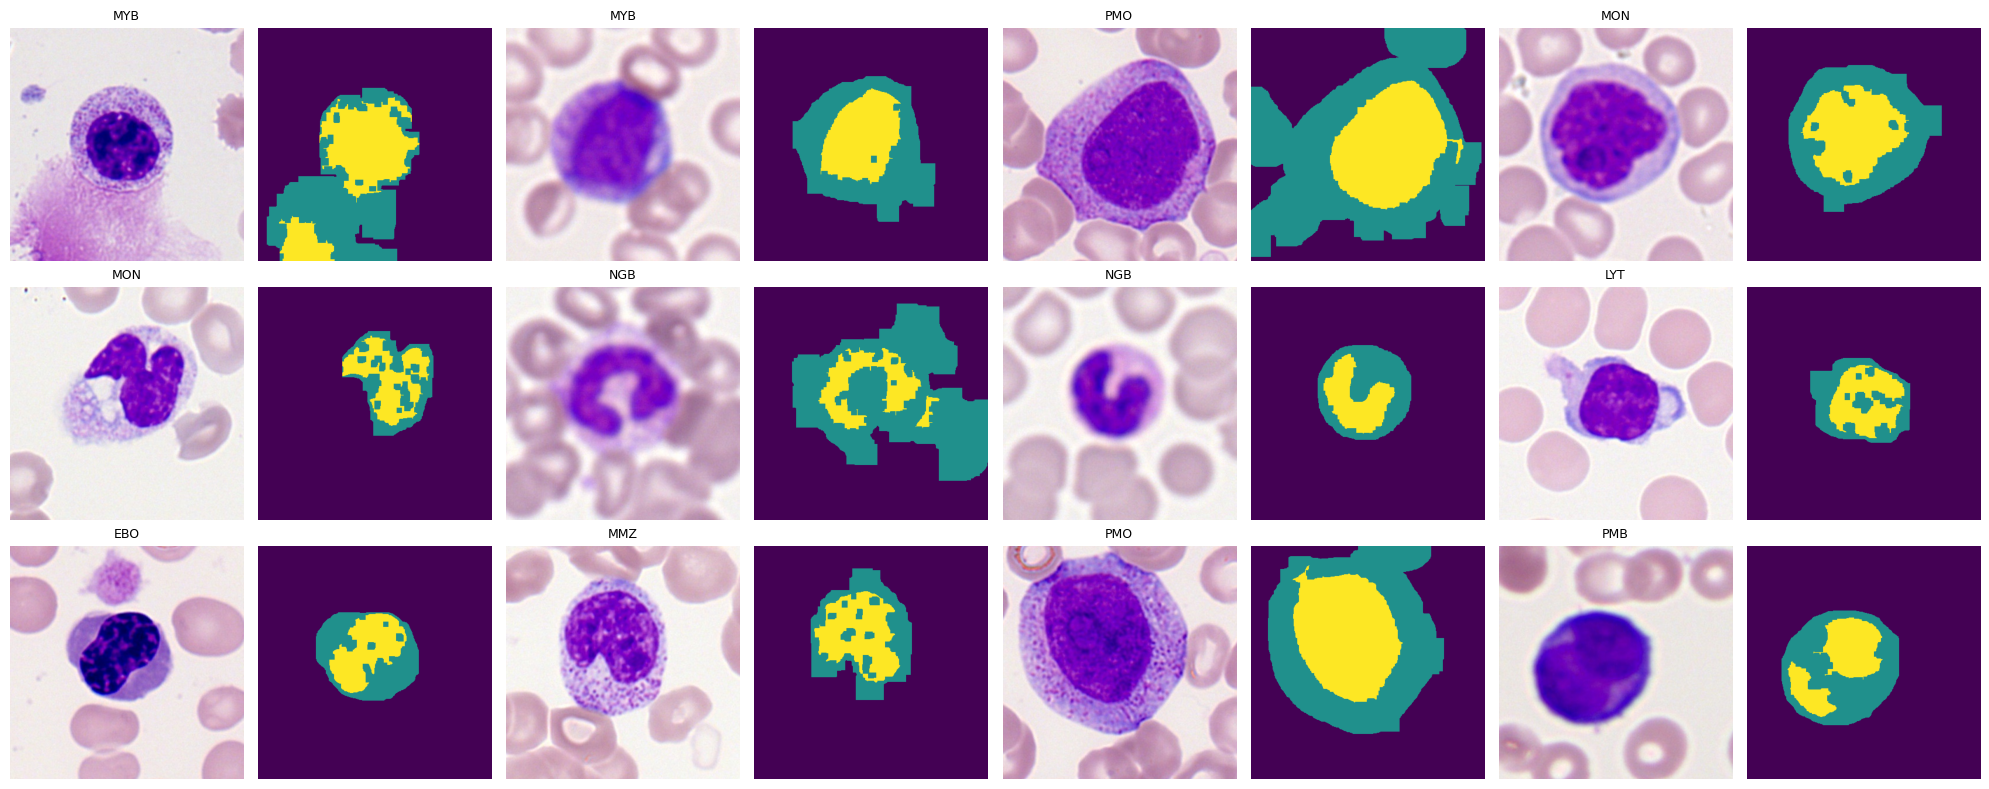

In [41]:
sample_check = subset_df.sample(12, random_state=1)

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
for i, (idx, row) in enumerate(sample_check.iterrows()):
    image_bgr = cv2.imread(row["path"])
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mask_path = os.path.join(AML_MASK_DIR, row["filename"].replace(".tiff", "_mask.png"))
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    r = (i // 4)
    c = (i % 4) * 2
    axes[r, c].imshow(image_rgb); axes[r, c].axis("off"); axes[r, c].set_title(row["class"], fontsize=9)
    axes[r, c+1].imshow(mask, cmap="viridis", vmin=0, vmax=2); axes[r, c+1].axis("off")

plt.tight_layout()
plt.show()

**Section 08 - Fine Tuning**

In [42]:
import shutil

LOCAL_AML_DIR = "/content/aml_local"
LOCAL_AML_IMG_DIR = os.path.join(LOCAL_AML_DIR, "images")
LOCAL_AML_MASK_DIR = os.path.join(LOCAL_AML_DIR, "masks")
os.makedirs(LOCAL_AML_IMG_DIR, exist_ok=True)
os.makedirs(LOCAL_AML_MASK_DIR, exist_ok=True)

new_paths = []
for _, row in subset_df.iterrows():
    dst_img = os.path.join(LOCAL_AML_IMG_DIR, row["filename"])
    if not os.path.exists(dst_img):
        shutil.copy(row["path"], dst_img)
    new_paths.append(dst_img)

    mask_filename = row["filename"].replace(".tiff", "_mask.png")
    src_mask = os.path.join(AML_MASK_DIR, mask_filename)
    dst_mask = os.path.join(LOCAL_AML_MASK_DIR, mask_filename)
    if os.path.exists(src_mask) and not os.path.exists(dst_mask):
        shutil.copy(src_mask, dst_mask)

subset_df["path"] = new_paths
AML_MASK_DIR = LOCAL_AML_MASK_DIR

print("Copied", len(subset_df), "images+masks to local storage.")

Copied 352 images+masks to local storage.


In [43]:
from sklearn.model_selection import train_test_split

def safe_split(df, test_size, stratify_col, seed=42):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[stratify_col], random_state=seed)
    except ValueError:
        print("Stratified split failed (some class too small) - falling back to plain random split")
        return train_test_split(df, test_size=test_size, random_state=seed)

train_df, temp_df = safe_split(subset_df, 0.3, "class")
val_df, test_df = safe_split(temp_df, 0.5, "class")
print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

train: 246 val: 53 test: 53


In [44]:
class AMLDataset(Dataset):
    def __init__(self, df, mask_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        mask_filename = self.df.loc[idx, "filename"].replace(".tiff", "_mask.png")
        mask_path = os.path.join(self.mask_dir, mask_filename)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [45]:
AML_IMG_SIZE = 256  # smaller than WBCAtt+'s 360 - AML images are cropped, this is fine

aml_train_aug = A.Compose([
    A.Resize(AML_IMG_SIZE, AML_IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.Affine(translate_percent=0.1, scale=(0.9, 1.1), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
aml_val_aug = A.Compose([
    A.Resize(AML_IMG_SIZE, AML_IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

aml_train_ds = AMLDataset(train_df, AML_MASK_DIR, transform=aml_train_aug)
aml_val_ds = AMLDataset(val_df, AML_MASK_DIR, transform=aml_val_aug)
aml_test_ds = AMLDataset(test_df, AML_MASK_DIR, transform=aml_val_aug)

aml_train_loader = DataLoader(aml_train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
aml_val_loader = DataLoader(aml_val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
aml_test_loader = DataLoader(aml_test_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("AML train batches:", len(aml_train_loader))
print("AML val batches:", len(aml_val_loader))
print("AML test batches:", len(aml_test_loader))

AML train batches: 31
AML val batches: 7
AML test batches: 7


In [46]:
def fine_tune_on_aml(source_checkpoint_path, backbone, use_rfg, max_epochs=30, patience=6, lr=2.5e-5,
                      train_loader=None, val_loader=None, run_name_suffix=""):
    train_loader = aml_train_loader if train_loader is None else train_loader
    val_loader = aml_val_loader if val_loader is None else val_loader

    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    model.load_state_dict(torch.load(source_checkpoint_path, map_location=device))
    print("Loaded pretrained weights from:", source_checkpoint_path)

    run_name = f"aml_finetune_{backbone}_rfg{int(use_rfg)}{run_name_suffix}"

    loss_fn = TotalLoss(lambda1=0.5, lambda2=0.3, lambda3=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_dice, best_ratio_error, epochs_no_improve = 0, float("inf"), 0
    history = []
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")

    for epoch in range(max_epochs):
        model.train()
        train_loss, n_batches = 0, 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            if use_rfg:
                loss = loss_fn(logits, masks, rfg_ratio=model.rfg.last_ratio)
            else:
                loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_batches += 1
        train_loss /= n_batches
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, val_loader, loss_fn)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        history.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_dice": val_dice, "val_ratio_error": val_ratio_error})

        is_better = (val_ratio_error < best_ratio_error) or (
            val_ratio_error == best_ratio_error and val_dice > best_dice
        )
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    pd.DataFrame(history).to_csv(os.path.join(LOG_DIR, run_name + "_history.csv"), index=False)
    print("Fine-tuning finished. Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)
    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error, "checkpoint_path": checkpoint_path}

In [63]:
best_phase1_checkpoint = os.path.join(CHECKPOINT_DIR, best_run_name + ".pt")

result = fine_tune_on_aml(best_phase1_checkpoint, backbone=PHASE2_BACKBONE, use_rfg=PHASE2_USE_RFG, max_epochs=30, patience=6, lr=1e-4)
print(result)

Loaded pretrained weights from: /content/drive/MyDrive/AML_ratio_project/checkpoints_v2/attention_unet_rfg1_ratio0_seed2.pt
Epoch 1: train_loss=0.5317 val_dice=0.8270 val_ratio_error=0.1718
Epoch 2: train_loss=0.3027 val_dice=0.8427 val_ratio_error=0.2598
Epoch 3: train_loss=0.2645 val_dice=0.8598 val_ratio_error=0.2468
Epoch 4: train_loss=0.2432 val_dice=0.8619 val_ratio_error=0.3060
Epoch 5: train_loss=0.2438 val_dice=0.8638 val_ratio_error=0.1770
Epoch 6: train_loss=0.2289 val_dice=0.8686 val_ratio_error=0.2219
Epoch 7: train_loss=0.2240 val_dice=0.8792 val_ratio_error=0.1811
Early stopping at epoch 7
Fine-tuning finished. Best val dice: 0.8270391821861267 Best val ratio error: 0.17181962302752904
{'run_name': 'aml_finetune_attention_unet_rfg1', 'best_dice': 0.8270391821861267, 'best_ratio_error': 0.17181962302752904, 'checkpoint_path': '/content/drive/MyDrive/AML_ratio_project/checkpoints_v2/aml_finetune_attention_unet_rfg1.pt'}


In [48]:
def train_aml_from_scratch(backbone, use_rfg, max_epochs=30, patience=6, lr=2.5e-5,
                            train_loader=None, val_loader=None, run_name_suffix=""):
    train_loader = aml_train_loader if train_loader is None else train_loader
    val_loader = aml_val_loader if val_loader is None else val_loader

    model = make_model(backbone, num_classes=3, use_rfg=use_rfg).to(device)
    run_name = f"aml_scratch_{backbone}_rfg{int(use_rfg)}{run_name_suffix}"

    loss_fn = TotalLoss(lambda1=0.5, lambda2=0.3, lambda3=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_dice, best_ratio_error, epochs_no_improve = 0, float("inf"), 0
    checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")

    for epoch in range(max_epochs):
        model.train()
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            if use_rfg:
                loss = loss_fn(logits, masks, rfg_ratio=model.rfg.last_ratio)
            else:
                loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()
        scheduler.step()

        val_loss, val_dice, val_ratio_error = evaluate(model, val_loader, loss_fn)
        print(f"Epoch {epoch+1}: val_dice={val_dice:.4f} val_ratio_error={val_ratio_error:.4f}")

        is_better = (val_ratio_error < best_ratio_error) or (
            val_ratio_error == best_ratio_error and val_dice > best_dice
        )
        if is_better:
            best_dice, best_ratio_error, epochs_no_improve = val_dice, val_ratio_error, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break

    print("Finished. Best val dice:", best_dice, "Best val ratio error:", best_ratio_error)
    return {"run_name": run_name, "best_dice": best_dice, "best_ratio_error": best_ratio_error}

scratch_result = train_aml_from_scratch(PHASE2_BACKBONE, use_rfg=PHASE2_USE_RFG, max_epochs=30, patience=6, lr=1e-4)
print(scratch_result)

Epoch 1: val_dice=0.4928 val_ratio_error=0.5792
Epoch 2: val_dice=0.7035 val_ratio_error=0.2628
Epoch 3: val_dice=0.7816 val_ratio_error=0.2888
Epoch 4: val_dice=0.8188 val_ratio_error=0.4236
Epoch 5: val_dice=0.8468 val_ratio_error=0.2459
Epoch 6: val_dice=0.8545 val_ratio_error=0.2214
Epoch 7: val_dice=0.8612 val_ratio_error=0.3380
Epoch 8: val_dice=0.8669 val_ratio_error=0.1744
Epoch 9: val_dice=0.8758 val_ratio_error=0.1861
Epoch 10: val_dice=0.8814 val_ratio_error=0.2264
Epoch 11: val_dice=0.8794 val_ratio_error=0.2059
Epoch 12: val_dice=0.8853 val_ratio_error=0.2106
Epoch 13: val_dice=0.8896 val_ratio_error=0.1754
Epoch 14: val_dice=0.8906 val_ratio_error=0.2407
Finished. Best val dice: 0.8668880661328633 Best val ratio error: 0.17443339952400752
{'run_name': 'aml_scratch_attention_unet_rfg1', 'best_dice': 0.8668880661328633, 'best_ratio_error': 0.17443339952400752}


In [64]:
phase2_results = pd.DataFrame([
    {"regime": "AML-only (from scratch)", **scratch_result},
    {"regime": "WBCAtt+ pretrained + fine-tuned", **result},
])
print(phase2_results[["regime", "best_dice", "best_ratio_error"]])
phase2_results.to_csv(os.path.join(LOG_DIR, "phase2_comparison.csv"), index=False)

                            regime  best_dice  best_ratio_error
0          AML-only (from scratch)   0.866888          0.174433
1  WBCAtt+ pretrained + fine-tuned   0.827039          0.171820


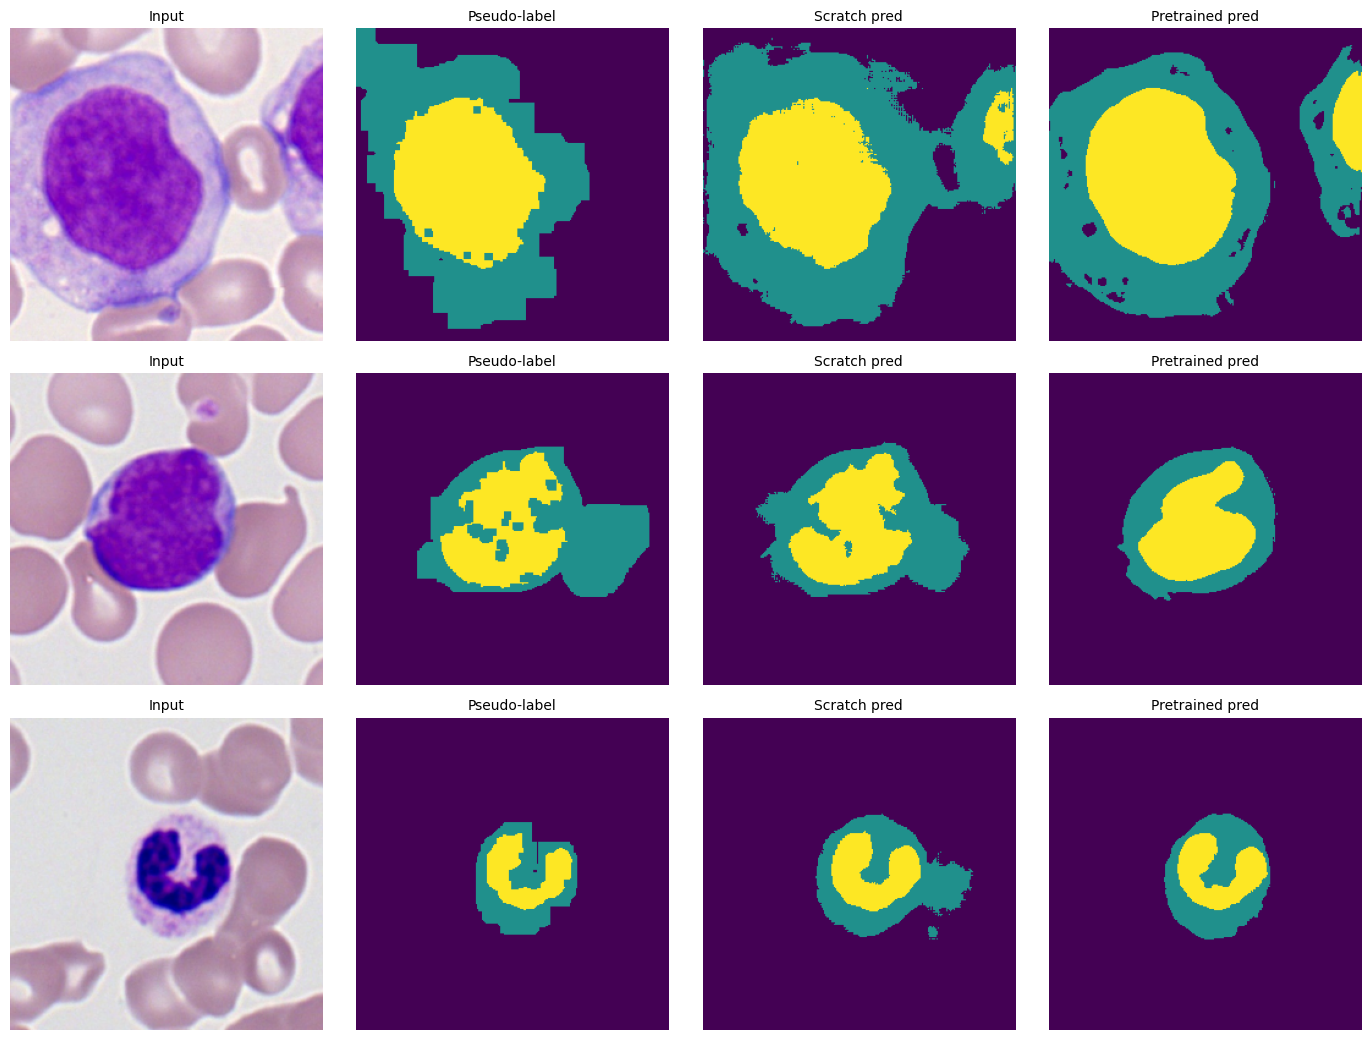

In [66]:
scratch_model = make_model(PHASE2_BACKBONE, num_classes=3, use_rfg=PHASE2_USE_RFG).to(device)
scratch_model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, f"aml_scratch_{PHASE2_BACKBONE}_rfg{int(PHASE2_USE_RFG)}.pt"), map_location=device))
scratch_model.eval()

pretrained_model = make_model(PHASE2_BACKBONE, num_classes=3, use_rfg=PHASE2_USE_RFG).to(device)
pretrained_model.load_state_dict(torch.load(
    os.path.join(CHECKPOINT_DIR, f"aml_finetune_{PHASE2_BACKBONE}_rfg{int(PHASE2_USE_RFG)}.pt"), map_location=device))
pretrained_model.eval()

images, masks = next(iter(aml_test_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    scratch_preds = torch.argmax(scratch_model(images), dim=1)
    pretrained_preds = torch.argmax(pretrained_model(images), dim=1)

n_show = min(3, images.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5 * n_show))
titles = ["Input", "Pseudo-label", "Scratch pred", "Pretrained pred"]

for i in range(n_show):
    img_np = images[i].cpu().permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    row_data = [img_np, masks[i].cpu(), scratch_preds[i].cpu(), pretrained_preds[i].cpu()]
    for j in range(4):
        if j == 0:
            axes[i, j].imshow(row_data[j])
        else:
            axes[i, j].imshow(row_data[j], cmap="viridis", vmin=0, vmax=2)
        axes[i, j].set_title(titles[j], fontsize=10)
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_phase2_comparison.png"), dpi=300)
plt.show()

In [67]:
images, masks = next(iter(aml_test_loader))
images, masks = images.to(device), masks.to(device)
with torch.no_grad():
    logits = pretrained_model(images)

# per_class_dice is already defined earlier (Section 6, cell c5ed73a1) - reused here.
print(per_class_dice(logits, masks))

{'background': 0.9698, 'cytoplasm': 0.7058, 'nucleus': 0.8333}


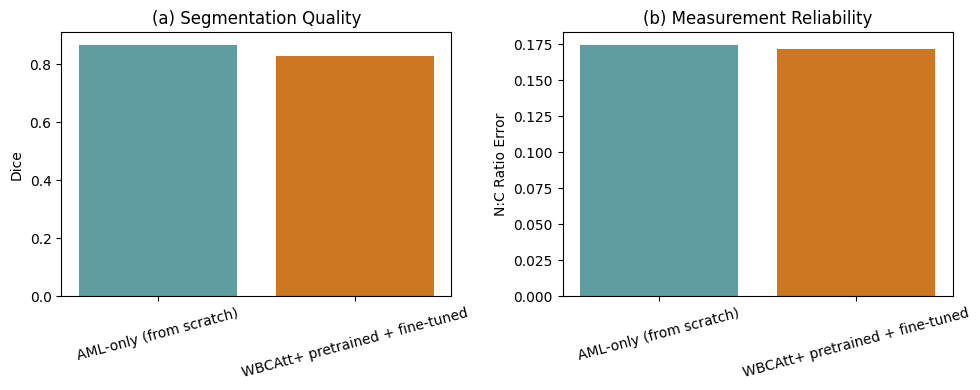

In [68]:
phase2_results = pd.read_csv(os.path.join(LOG_DIR, "phase2_comparison.csv"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(phase2_results["regime"], phase2_results["best_dice"], color=["#5F9EA0", "#CC7722"])
axes[0].set_ylabel("Dice"); axes[0].set_title("(a) Segmentation Quality")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(phase2_results["regime"], phase2_results["best_ratio_error"], color=["#5F9EA0", "#CC7722"])
axes[1].set_ylabel("N:C Ratio Error"); axes[1].set_title("(b) Measurement Reliability")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "fig_phase2_bars.png"), dpi=300)
plt.show()

**Section 09 - Phase II robustness check (repeated random splits)**

In [69]:
def build_aml_loaders(subset_df, seed, batch_size=8):
    """Re-splits subset_df with a given seed and builds fresh AML loaders.
    Reuses the aml_train_aug/aml_val_aug transforms already defined above -
    only the train/val/test partition changes per seed, not the augmentation."""
    train_df_s, temp_df_s = safe_split(subset_df, 0.3, "class", seed=seed)
    val_df_s, test_df_s = safe_split(temp_df_s, 0.5, "class", seed=seed)

    train_ds = AMLDataset(train_df_s, AML_MASK_DIR, transform=aml_train_aug)
    val_ds = AMLDataset(val_df_s, AML_MASK_DIR, transform=aml_val_aug)
    test_ds = AMLDataset(test_df_s, AML_MASK_DIR, transform=aml_val_aug)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f"seed {seed}: train={len(train_df_s)} val={len(val_df_s)} test={len(test_df_s)}")
    return train_loader, val_loader, test_loader

In [70]:
import gc

# Single train/val/test split gives one point estimate with no sense of how
# much it depends on which images happened to land in test. Repeating across
# several independent splits and reporting mean +/- std mirrors the same
# protection Phase I already gets from its 3-seed ablation.
PHASE2_SPLIT_SEEDS = [0, 1, 2, 3, 4]
phase2_multiseed_rows = []

for split_seed in PHASE2_SPLIT_SEEDS:
    print(f"\n=== Split seed {split_seed} ===")
    tr_loader, va_loader, te_loader = build_aml_loaders(subset_df, seed=split_seed)

    scratch_res = train_aml_from_scratch(
        PHASE2_BACKBONE, use_rfg=PHASE2_USE_RFG,
        max_epochs=30, patience=6, lr=1e-4,
        train_loader=tr_loader, val_loader=va_loader,
        run_name_suffix=f"_split{split_seed}",
    )
    scratch_res.update({"split_seed": split_seed, "regime": "AML-only (from scratch)"})
    phase2_multiseed_rows.append(scratch_res)

    finetune_res = fine_tune_on_aml(
        best_phase1_checkpoint, backbone=PHASE2_BACKBONE, use_rfg=PHASE2_USE_RFG,
        max_epochs=30, patience=6,
        train_loader=tr_loader, val_loader=va_loader,
        run_name_suffix=f"_split{split_seed}",
    )
    finetune_res.update({"split_seed": split_seed, "regime": "WBCAtt+ pretrained + fine-tuned"})
    phase2_multiseed_rows.append(finetune_res)

    gc.collect()
    torch.cuda.empty_cache()

phase2_multiseed_df = pd.DataFrame(phase2_multiseed_rows)
phase2_multiseed_df.to_csv(os.path.join(LOG_DIR, "phase2_multiseed_results.csv"), index=False)
print(phase2_multiseed_df[["regime", "split_seed", "best_dice", "best_ratio_error"]])


=== Split seed 0 ===
seed 0: train=246 val=53 test=53
Epoch 1: val_dice=0.5517 val_ratio_error=0.4926
Epoch 2: val_dice=0.7804 val_ratio_error=0.2166
Epoch 3: val_dice=0.8369 val_ratio_error=0.1870
Epoch 4: val_dice=0.8648 val_ratio_error=0.1667
Epoch 5: val_dice=0.8775 val_ratio_error=0.1571
Epoch 6: val_dice=0.8829 val_ratio_error=0.2749
Epoch 7: val_dice=0.8910 val_ratio_error=0.1655
Epoch 8: val_dice=0.8951 val_ratio_error=0.1864
Epoch 9: val_dice=0.8939 val_ratio_error=0.1335
Epoch 10: val_dice=0.8961 val_ratio_error=0.2961
Epoch 11: val_dice=0.9047 val_ratio_error=0.1824
Epoch 12: val_dice=0.9024 val_ratio_error=0.1544
Epoch 13: val_dice=0.9104 val_ratio_error=0.1273
Epoch 14: val_dice=0.9068 val_ratio_error=0.2055
Epoch 15: val_dice=0.9018 val_ratio_error=0.1312
Epoch 16: val_dice=0.9027 val_ratio_error=0.1443
Epoch 17: val_dice=0.9075 val_ratio_error=0.1869
Epoch 18: val_dice=0.9145 val_ratio_error=0.1247
Epoch 19: val_dice=0.9099 val_ratio_error=0.1478
Epoch 20: val_dice=0.91

In [71]:
from scipy import stats

summary = phase2_multiseed_df.groupby("regime").agg(
    dice_mean=("best_dice", "mean"), dice_std=("best_dice", "std"),
    ratio_err_mean=("best_ratio_error", "mean"), ratio_err_std=("best_ratio_error", "std"),
    n_splits=("split_seed", "count"),
).reset_index()
print(summary.to_string(index=False))
print()

scratch_vals = phase2_multiseed_df[phase2_multiseed_df["regime"] == "AML-only (from scratch)"].sort_values("split_seed")
finetune_vals = phase2_multiseed_df[phase2_multiseed_df["regime"] == "WBCAtt+ pretrained + fine-tuned"].sort_values("split_seed")

print("Paired t-test across matched splits (pretrained - scratch):")
for metric in ["best_dice", "best_ratio_error"]:
    t_stat, p_val = stats.ttest_rel(finetune_vals[metric].values, scratch_vals[metric].values)
    mean_diff = (finetune_vals[metric].values - scratch_vals[metric].values).mean()
    sig = "significant (p<0.05)" if p_val < 0.05 else "not significant"
    print(f"  [{metric}] mean_diff={mean_diff:+.4f}, p={p_val:.4f} ({sig}), n={len(scratch_vals)}")

                         regime  dice_mean  dice_std  ratio_err_mean  ratio_err_std  n_splits
        AML-only (from scratch)   0.910708  0.009582        0.116750       0.029003         5
WBCAtt+ pretrained + fine-tuned   0.872413  0.010802        0.171266       0.023280         5

Paired t-test across matched splits (pretrained - scratch):
  [best_dice] mean_diff=-0.0383, p=0.0047 (significant (p<0.05)), n=5
  [best_ratio_error] mean_diff=+0.0545, p=0.0650 (not significant), n=5
